<h1><center>Uke 3 - Polynomer og blindsonen</center></h1>

<h3><center>IMAG3011 – Matematikk for ingeniørfag 3A</h3>

<p><center><strong>Bjørn Ivar Thorsen Høie</strong></center></p>

<p><center>NTNU Gjøvik</center></p>

<p><center>September 2026</center></p>

<br>

<p><center>Hvordan kan matematisk likeverdige beskrivelser av det samme polynomrommet gi svært forskjellige numeriske resultater?</center></p>


## Innledening

In [2]:
import numpy as np
import matplotlib.pyplot as plt


def chebyshev_recursive(n, x):
    """Beregn T_n(x) direkte fra den rekursive definisjonen."""
    if n < 0:
        raise ValueError("n må være et ikke-negativt heltall")
    if n == 0:
        return 1 + 0*x       # TODO: forklar hvorfor 0*x er nyttig for arrays
    if n == 1:
        return x
    return (2*x*chebyshev_recursive(n-1, x)
            - chebyshev_recursive(n-2, x))


for n in range(5):
    print(f"T_{n}(0.3) = {chebyshev_recursive(n, 0.3): .8f}")

T_0(0.3) =  1.00000000
T_1(0.3) =  0.30000000
T_2(0.3) = -0.82000000
T_3(0.3) = -0.79200000
T_4(0.3) =  0.34480000


In [3]:
def chebyshev_table(x, n):
    """Returner en tabell med T_0(x), ..., T_n(x) som kolonner."""
    x = np.asarray(x, dtype=float)
    # En rad hører til én x-verdi. Den siste aksen reserveres for
    # polynomnummeret k: kolonne k inneholder T_k(x).
    table = np.empty(x.shape + (n+1,), dtype=float)
    table[..., 0] = 1.0
    if n >= 1:
        table[..., 1] = x
    # Tabellen tar vare på tidligere resultater. Derfor kan hver ny kolonne
    # bygges fra de to foregående uten å beregne dem på nytt.
    for k in range(1, n):
        table[..., k+1] = 2*x*table[..., k] - table[..., k-1]
    return table


x_test = np.array([-1.0, -0.25, 0.0, 0.4, 1.0])
print(chebyshev_table(x_test, 4))

[[ 1.      -1.       1.      -1.       1.     ]
 [ 1.      -0.25    -0.875    0.6875   0.53125]
 [ 1.       0.      -1.      -0.       1.     ]
 [ 1.       0.4     -0.68    -0.944   -0.0752 ]
 [ 1.       1.       1.       1.       1.     ]]


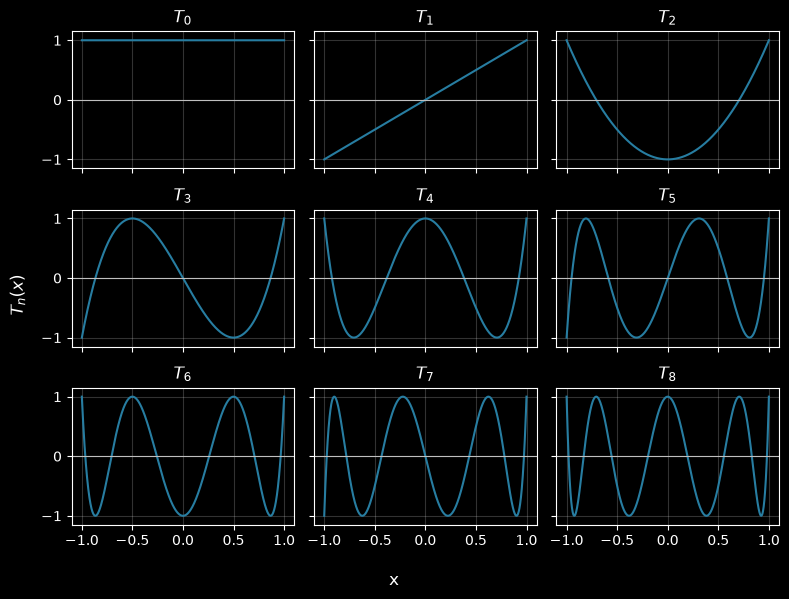

In [4]:
import numpy as np
import matplotlib.pyplot as plt

x_plot = np.linspace(-1.0, 1.0, 1200)
# Tabellen gjør at vi beregner alle ni kurvene i ett kall. T_plot[:, n]
# betyr: alle x-rader, men bare kolonnen som hører til T_n.
T_plot = chebyshev_table(x_plot, 8)

plt.close("all")
fig, axes = plt.subplots(3, 3, figsize=(8, 6), sharex=True, sharey=True)
for n, ax in enumerate(axes.ravel()):
    ax.plot(x_plot, T_plot[:, n], color="#277da1")
    ax.axhline(0, color="0.75", linewidth=0.8)
    ax.set_title(f"$T_{n}$")
    ax.grid(alpha=0.2)
    ax.set_ylim(-1.15, 1.15)
fig.supxlabel("x")
fig.supylabel("$T_n(x)$")
plt.tight_layout()
plt.show()

In [5]:
# Hver kolonne skal inneholde monomialkoeffisientene til ett T_k.
# Rekkefølgen på radene er 1, x, x^2, x^3, x^4.
Q = np.full((5, 5), np.nan)
# Kolonne k er koeffisientlisten til T_k. Rangtesten undersøker om de fem
# listene, og dermed de fem polynomene, er lineært uavhengige.
Q[:, 0] = [1, 0, 0, 0, 0]  # T_0
Q[:, 1] = [0, 1, 0, 0, 0]  # T_1

# TODO: Fyll kolonne 2, 3 og 4 fra håndregningen.
Q[:, 2] = [-1, 0, 2, 0, 0]
Q[:, 3] = [0, -3, 0, 4, 0]
Q[:, 4] = [1, 0, -8, 0, 8]


if np.isnan(Q).any():
    print("Fyll inn de tre siste kolonnene før rangtesten.")
else:
    print("Rang:", np.linalg.matrix_rank(Q))
    print("Diagonal:", np.diag(Q))

Rang: 5
Diagonal: [1. 1. 2. 4. 8.]


## Del 1: Reverse Enegineering fra polynomverdier

### Bygg avlesningsmatrisene for hånd

In [6]:
def monomial_matrix(points, n):
    """Avlesningsmatrise for basisen (1, x, ..., x^n)."""
    points = np.asarray(points, dtype=float)
    powers = np.arange(n+1)
    # points[:, None] lager en punktkolonne, og powers[None, :] lager en
    # potensrad. NumPy kombinerer dem til alle x_i**j samtidig.
    # TODO: Erstatt neste linje med uttrykket points[:, None] opphøyd i
    # powers[None, :]. Kontroller resultatet mot minieksemplene over.
    #points[:, 0] = [1,-1,1,-1] #T_0
    #points[:, 1] = [1,-1/3,7/9,-23/27] #T_1
    #points[:, 2] = [1,1/3,-7/9,-23/27] #T_2
    #points[:, 3] = [1,1,1,1] #T_3

    #raise NotImplementedError("Fullfør monomial_matrix før du går videre")
    return points[:, None] ** powers[None, :]


def chebyshev_matrix(points, n):
    """Avlesningsmatrise for basisen (T_0, ..., T_n)."""
    # chebyshev_table har allerede riktig design: rad i = punkt x_i og
    # kolonne k = T_k evaluert i alle punktene.
    return chebyshev_table(points, n)


points_small = np.array([-1.0, -1/3, 1/3, 1.0])
M_small = monomial_matrix(points_small, 3)
C_small = chebyshev_matrix(points_small, 3)

print("Monomialbasis:\n", M_small)
print("\nChebyshev-basis:\n", C_small)
print("\nRanger:", np.linalg.matrix_rank(M_small),
      np.linalg.matrix_rank(C_small))

Monomialbasis:
 [[ 1.         -1.          1.         -1.        ]
 [ 1.         -0.33333333  0.11111111 -0.03703704]
 [ 1.          0.33333333  0.11111111  0.03703704]
 [ 1.          1.          1.          1.        ]]

Chebyshev-basis:
 [[ 1.         -1.          1.         -1.        ]
 [ 1.         -0.33333333 -0.77777778  0.85185185]
 [ 1.          0.33333333 -0.77777778 -0.85185185]
 [ 1.          1.          1.          1.        ]]

Ranger: 4 4


#### Oppgaver til koden over
**Oppgave 1**

Definisjons rommet:
$$P_3 = {a_0+a_1x+a_2x^2+a_3x^3}$$


$$
\text{Verdirommet} = \begin{bmatrix}
p(x_0) \\
p(x_1) \\
p(x_2) \\
p(x_3)
\end{bmatrix}
$$

<br>

**Oppgave 2**

Koeffisentkollen til `M_small` er:
$$
a = \begin{bmatrix}
a_0 \\
a_1 \\
a_2 \\
a_3
\end{bmatrix}
$$
, og har polynomet
$$p(x)=a_0+a_1x+a_2x+a_3x$$

For eksempel så er tredje rad 3 i M_small:
$$ [1, 1/3, 1/9, 1/27] $$

Når vi ganger raden med a blir det
$$ a_0, -1/3a_1+1/9a_2+1/27a_3 $$

som er det samme som
$$ p(-1/3) $$

Derfor er verdidene `M_small @ a` lik $E(p)$

<br>

**Oppgave 3**

Forskjellen mellom `M_small` og `C_small` er at de bryker forskjellige byggeklossser.

`M_small` bruker monomialbasisen:
$$ (1,x,x^2,x^3) $$

`C_small` bruker Chebyshev basen:
$$ (T_0,T_1,T_2,T_3) $$

De ender opp med å bruke det samme polynomet og de samme fire punktene, men det blir forskejllige koeffisientkolonner.

<br>

**Oppgave 4**

Rang 4 betyr at nullrommet bare inneholder nullvektoren. Derfor kan to forskjellige polynomer i $P_3$ ha like avlesninger.

<br>

**Oppgave 5**

Selv om koeffientkollene er forskjellige så ender de opp med det samme polynomet, med forskjellige basiser. For å kontroller svaret kann mann ta og sammenligne avlesningene:
$$ Ma = Cc$$

### Skriv det samme polynomet i to basiser

In [7]:
from numpy.polynomial import polynomial as poly
from numpy.polynomial import chebyshev as cheb

monomial_true = np.array([1.0, -2.0, 0.5, 1.0])
# Dette er de eneste dataene de to lineære systemene får.
measurements_small = poly.polyval(points_small, monomial_true)

# Begge systemene har formen «avlesningsmatrise @ koordinater = data».
# solve returnerer koordinatene; hvilken basis de tilhører bestemmes av
# matrisen på venstre side.
monomial_recovered = np.linalg.solve(M_small, measurements_small)
chebyshev_recovered = np.linalg.solve(C_small, measurements_small)

print("Avlesninger:", measurements_small)
print("Monomialkoordinater:", monomial_recovered)
print("Chebyshev-koordinater:", chebyshev_recovered)

x_dense = np.linspace(-1, 1, 1001)
p_reference = poly.polyval(x_dense, monomial_true)
p_from_monomials = poly.polyval(x_dense, monomial_recovered)
p_from_chebyshev = cheb.chebval(x_dense, chebyshev_recovered)

print("Største forskjell, monomial:",
      np.max(np.abs(p_from_monomials-p_reference)))
print("Største forskjell, Chebyshev:",
      np.max(np.abs(p_from_chebyshev-p_reference)))

Avlesninger: [2.5        1.68518519 0.42592593 0.5       ]
Monomialkoordinater: [ 1.  -2.   0.5  1. ]
Chebyshev-koordinater: [ 1.25 -1.25  0.25  0.25]
Største forskjell, monomial: 4.440892098500626e-16
Største forskjell, Chebyshev: 4.440892098500626e-16


![Kontroll](bilder/Kontroll.jpg)

### Finn det avlesningene ikke kan se

In [8]:
# Forsøk A: Fjern den siste avlesningen.
points_three = points_small[:-1]
M_three = monomial_matrix(points_three, 3)

# Forsøk B: Bruk fire plasser, men les av samme punkt to ganger.
points_repeated = np.array([-1.0, -1/3, 1/3, 1/3])
M_repeated = monomial_matrix(points_repeated, 3)

print("Form og rang med tre avlesninger:",
      M_three.shape, np.linalg.matrix_rank(M_three))
print(points_small)
print("Form og rang med gjentatt punkt:",
      M_repeated.shape, np.linalg.matrix_rank(M_repeated))
print(points_small)

Form og rang med tre avlesninger: (3, 4) 3
[-1.         -0.33333333  0.33333333  1.        ]
Form og rang med gjentatt punkt: (4, 4) 3
[-1.         -0.33333333  0.33333333  1.        ]


**Finn et ikke null polynom**
 ![Ikke-null polynom](bilder/NullPoly.jpeg)

Største avvik fra polyfromroots: 2.7755575615628914e-17
Koeffisienter til z: [-0.11111111 -0.11111111  1.          1.        ]
Avlesninger av p:        [2.5        1.68518519 0.42592593]
Avlesninger av p+alpha*z: [2.5        1.68518519 0.42592593]
Forskjell i avlesningene: [ 0.00000000e+00  0.00000000e+00 -5.55111512e-17]


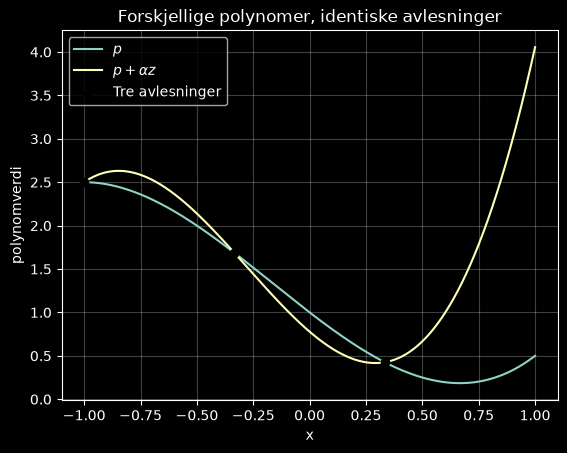

In [9]:
invisible_coefficients = np.array([-1/9, -1/9, 1, 1])
if np.isnan(invisible_coefficients).any():
    raise ValueError("Fyll inn koeffisientene til z før du går videre")

# Biblioteket brukes her bare som en uavhengig kontroll av håndregningen.
coefficients_check = poly.polyfromroots(points_three)
print("Største avvik fra polyfromroots:",
      np.max(np.abs(invisible_coefficients-coefficients_check)))

# Velg selv en synlig skaleringsfaktor.
alpha = 2.0
second_polynomial = monomial_true + alpha*invisible_coefficients

# De to polynomene er forskjellige, men z er null i alle tre punktene.
first_values = poly.polyval(points_three, monomial_true)
second_values = poly.polyval(points_three, second_polynomial)

print("Koeffisienter til z:", invisible_coefficients)
print("Avlesninger av p:       ", first_values)
print("Avlesninger av p+alpha*z:", second_values)
print("Forskjell i avlesningene:", second_values-first_values)

plt.close("all")
plt.plot(x_dense, poly.polyval(x_dense, monomial_true), label="$p$")
plt.plot(x_dense, poly.polyval(x_dense, second_polynomial),
         label="$p+\\alpha z$")
plt.scatter(points_three, first_values, color="black", zorder=3,
            label="Tre avlesninger")
plt.xlabel("x")
plt.ylabel("polynomverdi")
plt.title("Forskjellige polynomer, identiske avlesninger")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

**Oppgave 1**

Når vi regner ut $E(z)$ for de tre punktene [-1, -1/3, 1/3] for vi null i alle tilfellene. Selv om z ikke er et nullpolynom så betyr det ikke at den kan ha $z-verdier$ som er null. For å være et null polynom måtte alle typer $z$ verdier gitt null i svar, regner vi f.eks. med $z=1$ får vi ikke null, men $\frac{16}{9}$.
 ![IkkeNullPoly](bilder/ENullPoly.jpeg)

<br>

**Oppgave 2**

På grunn av linearitet kan vi skrive $E(p+\alpha z)$ om til:
$$
E(p+\alpha z) = E(p) + \alpha E(z)
$$
Siden $E(z) blir null blir utrykket
$$
E(p+\alpha z) = E(p)
$$
Dermed spiller ikke $\alpha$ en rolle på utrykket og den kan være hvilket som helst tall.

<br>

**Oppgave 3**

$P_3$ har dimensjonen $n+1=3+1=4$. Da blir avlesningsmatrisen
$$
\begin{bmatrix}
1 & 1 & 1 & -1 \\
1 & -1/3 & 1/9 & -1/27\\
1 & 1/3 & 1/9 & 1/27
\end{bmatrix}
$$

Siden matrisen har 3 rader så
$$
\text{rang}(a) = 3
$$

<br>

**Oppgave 4**

Ved rang-nullitet blir det:

$$
\dim(\ker(A))+{rang}(A)=4
$$

$$
\dim(\ker(A))+3=4
$$

$$
\dim(\ker(A))=1
$$

Det betyr at det finnes en uavhengig måte å endre et polynom på uten at de tre avlesningene endres.

<br>

**Oppgave 5**

Vi trenger fire forskjellige punkter slik vi får fire forskjellige radier i avlesningsmatrisen. Bruker vi samme punkt så leser vi bare det samme punktet omigjen. For eksempel når originalt hadde vi punkt $frac{1}{3}$ skrevet to ganger, og det ga to identiske rader.

## Del 2: Hold punktene fast og bytt basis


In [10]:
def chebyshev_points(n):
    """Returner n+1 cosinusfordelte punkter i intervallet [-1,1]."""
    # P_n har dimensjon n+1, så vi bruker n+1 forskjellige avlesninger.
    k = np.arange(n+1)
    return np.cos((2*k+1)*np.pi/(2*(n+1)))


def reference_coordinates(n):
    """Moderate, deterministiske koordinater i Chebyshev-basis."""
    # En fast formel gir samme referansepolynom hver gang forsøket gjentas.
    # Avtagende koeffisienter hindrer at vi bygger inn store tall med vilje.
    k = np.arange(n+1)
    return (-1.0)**k/(k+1.0)**2


def max_grid_error(values, reference):
    # Maksimum på et tett rutenett er en numerisk måling, ikke et bevis på
    # maksimum over alle reelle x i intervallet.
    return float(np.max(np.abs(values-reference)))

 Jeg tror at monomialkoeffisientene ikke blir små. Chebyshev-polynomiene får stadig større koeffisienter når de skrives som potenser av x. Derfor forventer jeg at koeffisientene i monomialbasis kan bli store ved en høy grad som 30.

### Gjør reverse engineering i begge basiser

In [11]:
def compare_bases(n, grid_size=2001):
    # Det samme polynomet leses av i de samme punktene for begge basiser.
    points = chebyshev_points(n)
    true_chebyshev = reference_coordinates(n)
    measurements = cheb.chebval(points, true_chebyshev)

    # Bare koordinatsystemet endres mellom de to lineære systemene.
    M = monomial_matrix(points, n)
    C = chebyshev_matrix(points, n)

    # Reverse engineering i to basiser: solve finner koeffisientene som gir
    # de oppgitte avlesningene. Svarvektorene kan ikke sammenlignes ledd for
    # ledd fordi basisene er ulike.
    recovered_monomial = np.linalg.solve(M, measurements)
    recovered_chebyshev = np.linalg.solve(C, measurements)

    # Det tette rutenettet gir ingen nye data til systemet. Det brukes bare
    # til å sammenligne de to ferdige polynomene mellom avlesningspunktene.
    grid = np.linspace(-1.0, 1.0, grid_size)
    reference = cheb.chebval(grid, true_chebyshev)
    from_monomials = poly.polyval(grid, recovered_monomial)
    from_chebyshev = cheb.chebval(grid, recovered_chebyshev)

    return {
        "n": n,
        "points": points,
        "measurements": measurements,
        "grid": grid,
        "reference": reference,
        "monomial_values": from_monomials,
        "chebyshev_values": from_chebyshev,
        "monomial_coordinates": recovered_monomial,
        "chebyshev_coordinates": recovered_chebyshev,
        "monomial_error": max_grid_error(from_monomials, reference),
        "chebyshev_error": max_grid_error(from_chebyshev, reference),
    }


basis_data = compare_bases(30)
monomial_errors = (
    basis_data["monomial_values"] - basis_data["reference"]
)

chebyshev_errors = (
    basis_data["chebyshev_values"] - basis_data["reference"]
)

print("Grad:", basis_data["n"])
print("Største |monomialkoordinat|:",
      np.max(np.abs(basis_data["monomial_coordinates"])))
print("Største |Chebyshev-koordinat|:",
      np.max(np.abs(basis_data["chebyshev_coordinates"])))
print("Maksfeil med monomialbasis:", basis_data["monomial_error"])
print("Maksfeil med Chebyshev-basis:", basis_data["chebyshev_error"])

# Retrieve the index of the error
monimal_index = np.argmax(np.abs(monomial_errors))
chebyshev_index = np.argmax(np.abs(chebyshev_errors))

# Retrieve the error and its x value
monimal_x = basis_data["grid"][monimal_index]
monimal_error = monomial_errors[monimal_index]

chebysheev_x = basis_data["grid"][chebyshev_index]
chebysheev_error = chebyshev_errors[chebyshev_index]

print()

print(
    "Største monomialfeil:",
    "x =", monimal_x,
    "feil =", monimal_error
)

print(
    "Største Chebyshev-feil:",
    "x =", chebysheev_x,
    "feil =", chebysheev_error
)

Grad: 30
Største |monomialkoordinat|: 32003948.208880924
Største |Chebyshev-koordinat|: 0.9999999999999999
Maksfeil med monomialbasis: 1.0649563453313249e-08
Maksfeil med Chebyshev-basis: 8.881784197001252e-16

Største monomialfeil: x = -0.667 feil = -1.0649563453313249e-08
Største Chebyshev-feil: x = -1.0 feil = 8.881784197001252e-16


#### Oppgaver

1. `measurements` lages kun en gang i koden i funksjonen `compare_bases` og bruks som høyreside for de linære systemene, $Ma = y$ og $Cc = y$. Da får begge systemene samme avlesningsvrdiene siden begge bruker samme `measurement`, og eneste forskjellen er hva som ligger på venstresiden, altså hvilken basis som brukes.
2. Den største koeffisienten i monimalbasis er cirka $3.2*10^7$, mens den største i Chbyshevbasis er cirka $0.9999$. Forskjellen mellom dem i tierpotens er cirka $10e7$.
3. Den største fielen for monomialbasisen er $-1.0649563453313249e-08$ og ligger i $x=-0.677$, mens for Chebyshev basisen er feilen på $8.881784197001252e-16$. Forskjellen mellom dem i tierbasis er $10^6$ og ligger i $x=-1$.
4. Begge basisene beskriver det samme polynomrom $n = 30$. Det samme polynomrmmet `true_chebyshev` brukes for begge metodene. Begge metodene brukr samme avlesningspunkter `points`. Begge bruker også det samme avlesningsvrdiene `measurments`, eneste forskjellen er venstresiden av avlesningsmatrisen.
5. Begge basisene er likeverdig, og begger beskriver det samme polynomet. Forskjellen i de beregnede feilene skyldes flyttallsregning. Når bi bruker grad 30 blir monomialkoeffisintene store, dermed blir det utregningene ikke helt nøyaktige. Dette fører til flyttallsfeil og avrundingsfeil som skaper forskjell i resultatene.

### Legg den samme lille feilen til begge systemene

In [12]:
n = 30
points = chebyshev_points(n)
true_chebyshev = reference_coordinates(n)
measurements = cheb.chebval(points, true_chebyshev)

rng = np.random.default_rng(2026)
# Fast startverdi gjør forsøket reproduserbart: alle får nøyaktig samme
# forstyrrelse når cellen kjøres på nytt.
measurement_noise = 1e-10*rng.standard_normal(n+1)

M = monomial_matrix(points, n)
C = chebyshev_matrix(points, n)

a_before = np.linalg.solve(M, measurements)
a_after = np.linalg.solve(M, measurements+measurement_noise)
c_before = np.linalg.solve(C, measurements)
c_after = np.linalg.solve(C, measurements+measurement_noise)

# Normen samler endringene i hele koordinatvektoren til ett tall. Vi
# sammenligner før og etter innen samme basis, ikke koeffisienter på tvers.
print("Største endring i avlesning:", np.max(np.abs(measurement_noise)))
print("Endring i monomialkoordinater:", np.linalg.norm(a_after-a_before))
print("Endring i Chebyshev-koordinater:", np.linalg.norm(c_after-c_before))

Største endring i avlesning: 1.8963263495990658e-10
Endring i monomialkoordinater: 0.7437193934839046
Endring i Chebyshev-koordinater: 1.1441794460616513e-10


I selve dataen så ble endringen på cirka $1.89e-10$. Dette førte til at monomialkofessitene fikk en endring på cirka $0.74$ og chebshev koeffsientene fikk en endring på cirka $1.14e-10$. Endringen var størt for monimal koeffisientene så det var denne representasjonen som forsterket dataendringene mest.

## Del 3

### Sammenlign punktplasseringene før du regner

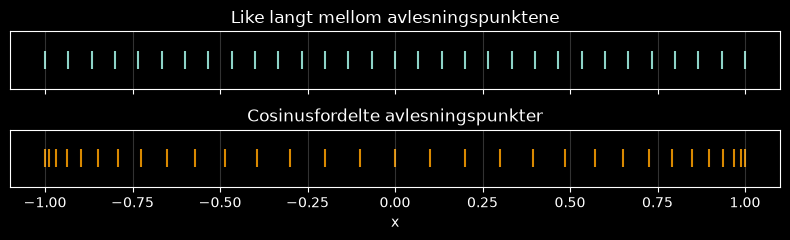

In [13]:
n = 30
equal_points = np.linspace(-1.0, 1.0, n+1)
cheb_points = chebyshev_points(n)

# Punktene tegnes på hver sin tallinje før løsing. Figuren kontrollerer den
# variabelen vi skal endre: punktplasseringen.
plt.close("all")
fig, axes = plt.subplots(2, 1, figsize=(8, 2.5), sharex=True)
axes[0].scatter(equal_points, np.zeros_like(equal_points), marker="|", s=180)
axes[0].set_title("Like langt mellom avlesningspunktene")
axes[1].scatter(cheb_points, np.zeros_like(cheb_points), marker="|", s=180,
                color="#d98900")
axes[1].set_title("Cosinusfordelte avlesningspunkter")
for ax in axes:
    ax.set_yticks([])
    ax.grid(axis="x", alpha=0.2)
axes[1].set_xlabel("x")
plt.tight_layout()
plt.show()

Hypotese: Hvis et polynom er tvunget til å passe data i mange punkter nær endene, blir det da lettere eller vanskeligere for polynomet å få store utslag der mellom avlesningene?

#### Oppgave

På det første plottet så er det lik avstand mellom vær av avlesningspunktene. Avstanden blir regnet ut i `equal_points` variabelen. Men i den cosniusfordelte avstandne så ser vi at den har fordelt punktene tettere det nærmere x er -1 og 1.

**Hvilket oppsett ville du valgt dersom du var spesielt redd for at polynomet skulle gjøre noe uventet nær −1 eller 1?**<br>
Hyptoese: Ut ifra plottene så ville jeg valgt den cosinusfordelte punktene, da hvis noe uventet skulle skje nærmere -1 og 1 så ville vi hatt mer data rundt de to områdene.



### Bruk den samme lile feilen med begge punktsettene

Forstyrrer avlesning med:
$$𝛿⁢𝑦𝑘=10−10⁢(−1)𝑘.$$

Forholdet
$$
\frac{\text{største feil på det tette rutenettet}}{\text{største feil i de oppgitte avlesningene}}
$$
kalles for forsterkningen

In [14]:
def point_placement_experiment(n, points, noise_size=1e-10,
                               grid_size=5001):
    # Lag de nøyaktige avlesningene fra ett fast referansepolynom.
    true_coordinates = reference_coordinates(n)
    measurements = cheb.chebval(points, true_coordinates)
    # Det samme fortegnsmønsteret brukes uansett hvor punktene ligger.
    noise = noise_size*(-1.0)**np.arange(n+1)

    # Reverse engineering: Finn koeffisientene til polynomet som passer til
    # de litt forstyrrede avlesningene.
    C = chebyshev_matrix(points, n)
    recovered = np.linalg.solve(C, measurements+noise)

    # Sammenlign med referansepolynomet også mellom avlesningspunktene. Det
    # tette rutenettet påvirker ikke løsningen; det fungerer som måleinstrument.
    grid = np.linspace(-1.0, 1.0, grid_size)
    reference = cheb.chebval(grid, true_coordinates)
    perturbed = cheb.chebval(grid, recovered)
    error = perturbed-reference

    return {
        "n": n,
        "points": points,
        "noise": noise,
        "grid": grid,
        "error": error,
        "max_data_error": float(np.max(np.abs(noise))),
        "max_curve_error": float(np.max(np.abs(error))),
    }


equal_data = point_placement_experiment(
    n, equal_points, noise_size=1e-10
)
cheb_data = point_placement_experiment(
    n, cheb_points, noise_size=1e-10
)

for name, data in [("Jevne punkter", equal_data),
                   ("Cosinusfordelte punkter", cheb_data)]:
    amplification = data["max_curve_error"]/data["max_data_error"]
    print(f"{name:27s}",
          f"feil i avlesning={data['max_data_error']:.3e}",
          f"kurvefeil={data['max_curve_error']:.3e}",
          f"forsterkning={amplification:.3e}")

Jevne punkter               feil i avlesning=1.000e-10 kurvefeil=6.601e-04 forsterkning=6.601e+06
Cosinusfordelte punkter     feil i avlesning=1.000e-10 kurvefeil=3.149e-10 forsterkning=3.149e+00


Kurve feilen for jevne punkter er cirka $6.601e-04$, den er høyere enn kurvefeilen for de cosinus fordelte punktene, $3.149e-10$. Det er $10e6$ tierpotense som skiller kurvefeilen for de to metodene.

Forsterkningen for jevne punkter ligger på $6.601e+06$ og for cosnisfordelte punkter er den lavere og er $3.149e+00$. Det er $10e6$ tierpotenser som skiller forsterkningen også.

Forskjellen kan ikke skyldes ulik størrelse på forstyrrelsen, siden begge bruker samme forsyrrelse. Vi kan heller ikke skylde på ulik basis siden begge bruker begge chebyshev basis. Forskjellen kommer ifra hvilke punkter som blir valgt å bruke. Ved å bruke jevnt fordelte punkter så får vi et mer ustabilt system, mens med cosnisud fordelte punkter så får vi et mer stabilitet og mindre feil. Hyptoesen min stemmte her.

### Gjør det ensten usynlige feilpolynomet synlig

Forskjellen mellom reverse enginereering resultat og opprinnelige polynomet er selv et polynom:
$$
𝑟⁡(𝑥)=𝑝_{forstyrret}⁡(𝑥)−𝑝_{opprinnelig}⁡(𝑥)
$$

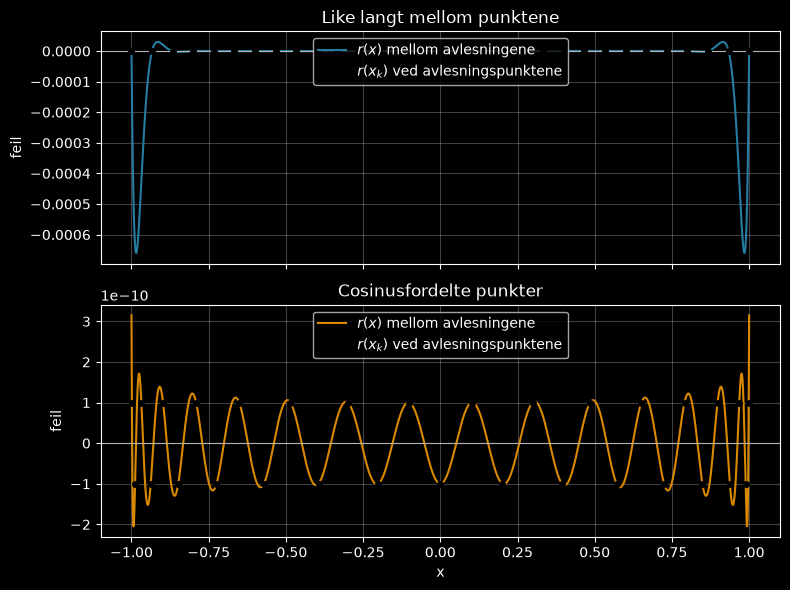

In [15]:
plt.close("all")
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

for ax, title, data, color in [
    (axes[0], "Like langt mellom punktene", equal_data, "#277da1"),
    (axes[1], "Cosinusfordelte punkter", cheb_data, "#d98900"),
]:

    ax.plot(data["grid"], data["error"], color=color,
            label="$r(x)$ mellom avlesningene")
    ax.scatter(data["points"], data["noise"], color="black", s=16,
               zorder=3, label="$r(x_k)$ ved avlesningspunktene")
    ax.axhline(0, color="0.7", linewidth=0.8)
    ax.set_title(title)
    ax.set_ylabel("feil")
    ax.grid(alpha=0.25)
    ax.legend(loc="upper center")

axes[1].set_xlabel("x")
plt.tight_layout()
plt.show()

#### Oppgaver

1. I plottet med jevnt fordelte punkter ser de hvite punktene ut til å ligge på null fordi y-aksen også må vise den langt større feilen mellom punktene. På hele rutenettet blir maksimum av $|r(x)|$ omtrent $6.6e-4$ for de jevnt fordelte punktene, mens det blir omtrent $3.2e{-10}$ for de cosinusfordelte punktene. Feilen mellom de jevnt fordelte punktene er derfor mye større enn feilen ved avlesningspunktene.
2. $|r(x)|$ blir størt i starten når x er -1 og i slutten når x er 1. Mellom det største $|r(x)|$ er det 2 punkter, så det er få avlesningpunkter i det området.
3. $|r(x)|$ blir størt i starten når x er -1 og i slutten når x er 1. I dette området er det flere punkter sammenlignet med det første plottet.
4. Likheten mellom r og z er at de begge er ikke-null polynomer. Forskjellen er at z ligger i det eksakte nullrommet, siden $E(z)=0$. Feilpolynomet r ligger ikke i nullrommet, fordi $E(r)$ består av verdier på $10e{-10}$. Derfor er r bare nesten usynlig for avlesningene og kan omtales som en numerisk nullromsretning

## Finale: Beregn det samme nullpolynomet på tre måter

$$
T_n(x)=cos(n\text{across}x), -1<=x<=1
$$

In [16]:
n = 50
x0 = 0.99

cheb_coordinates = np.zeros(n+1)
# Denne koordinatvektoren betyr 0*T_0 + ... + 1*T_50.
cheb_coordinates[n] = 1.0
# Konverteringen endrer koordinatene, ikke polynomet. Etterpå evalueres det
# samme matematiske objekt med to forskjellige representasjoner.
monomial_coordinates = cheb.cheb2poly(cheb_coordinates)

value_monomial = poly.polyval(x0, monomial_coordinates)
value_chebyshev = cheb.chebval(x0, cheb_coordinates)
value_reference = np.cos(n*np.arccos(x0))

print("Største monomialkoeffisient:",
      np.max(np.abs(monomial_coordinates)))
print("Monomialevaluering:   ", value_monomial)
print("Chebyshev-evaluering: ", value_chebyshev)
print("Cosinusreferanse:     ", value_reference)
print("Feil, monomial:       ", abs(value_monomial-value_reference))
print("Feil, Chebyshev:      ", abs(value_chebyshev-value_reference))

Største monomialkoeffisient: 1.2874559606751232e+18
Monomialevaluering:    -31.596144407541345
Chebyshev-evaluering:  0.7011491981769309
Cosinusreferanse:      0.7011491981769286
Feil, monomial:        32.297293605718274
Feil, Chebyshev:       2.3314683517128287e-15


In [17]:
print(f"{'grad':>5} {'største koeff.':>18} "
      f"{'feil monomial':>18} {'feil Chebyshev':>18}")
print("-"*63)

for n_test in [10, 20, 30, 40, 50]:
    c = np.zeros(n_test+1)
    c[n_test] = 1.0
    a = cheb.cheb2poly(c)
    reference = np.cos(n_test*np.arccos(x0))
    monomial_value = poly.polyval(x0, a)
    chebyshev_value = cheb.chebval(x0, c)
    print(f"{n_test:5d} {np.max(np.abs(a)):18.4e} "
          f"{abs(monomial_value-reference):18.4e} "
          f"{abs(chebyshev_value-reference):18.4e}")

 grad     største koeff.      feil monomial     feil Chebyshev
---------------------------------------------------------------
   10         1.2800e+03         4.8322e-14         1.8596e-15
   20         6.5536e+06         3.6029e-10         0.0000e+00
   30         3.6176e+10         8.0878e-07         1.7764e-15
   40         2.1236e+14         2.6183e-04         9.9920e-16
   50         1.2875e+18         3.2297e+01         2.3315e-15


#### Oppgaver

1. Størrelsen på et polynom måler funksjonens fysiske geometri, mens størrelsen på koeffsientene avhneger av hvilken basis som blir brukt.
2. Monomial koeffisientene vokser raskt når graden økes. Fra grad 10 til grad 50 vokser den fra $10e3$ til $10e18$. Samtidig skal $T_n(x)$ ligge mellom -1 og 1 på intervallet. Da må store positive og negative ledd kanselere hveradnre ut for å oppnå den lille sluttverdien. Problemet er at kanselleringen blir mer sårbar for avrundingsfeil etter hvert som koeffisientene vokser.
3. Fra prosjekt i uke 1 så vet vi at flyttall har et begrenset antall sifre, som fører til at de store mellomresultatene i monomialevalueringen blir avrundet. Så når store positive og negative ledd skal kanselere hverandre så vil vi miste noen sifre på grunn av avrundingsfeil. F.eks. på grad 50 så ser vi at feilen ligger på omtrent $32.3$, som er et problem siden svaret skal ligge i intervallet -1 og 1.
4.  Monomialbasis og Chebyshev basis beskriver det samme polynomet, men koeffisientene og bergeningsmåten er forskjellige. Siden monomialbasis bruker koeffisienter på opptil $1.29e18$, så vil dette føre til avrundingsfeil. Chebyshev bruker koordinater og kan evaluere direkte, som fører til at den gir bedre numerisk kvalitet. Sammenligner vi feilen for monomial og chebyshev så ser vi at chebyshev har en mye mindre feil og gjør det bedre.
5. Polynomet $T_{50}$ er allerede kjent og evalueres direkte ved $x=0.99$ på tre måter. Feilen kan derfor ikke skyldes plasseringen av avlesningspunkter. Den skyldes representasjonen av polynomet og avrundingen som oppstår når monomialformen evalueres med svært store koeffisienter.